# Proyecto Final — Analítica de Datos
## Análisis de Readmisiones Hospitalarias, Recurrencia y Estancia en Pacientes Diabéticos

**Universidad Iberoamericana · Primavera 2026**  
**Materia:** Analítica de datos  
**Profesor:** Rodrigo Cárdenas Domínguez  
**Alumnos:** Hector Raul Becerril Villamil, Elena Carolina Sánchez Araiza

---

Este cuaderno documenta el flujo completo del proyecto. La idea es sencilla: tomamos el dataset *Diabetes 130-Hospitals* (UCI / Kaggle), lo limpiamos, lo entendemos y después modelamos tres fenómenos clínicos — la readmisión temprana, la recurrencia de ingresos y la duración de la estancia. Cada sección tiene una nota previa explicando el *por qué* de las decisiones, no sólo el *qué*.

## 0. Imports y configuración

Agrupo todo aquí arriba para que se vea de un solo golpe lo que voy a necesitar. Siempre me pasa que termino importando a medias y luego el notebook está hecho un caos. Mejor declararlo una vez.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

import warnings
warnings.filterwarnings('ignore')   # los warnings de statsmodels son ruidosos

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

RUTA_DATOS = '/Users/hectorbecerrilvillamil/Desktop/ibero/DataAnalytics/proyecto/diabetic_data.csv'
SEMILLA = 42

## 1. Carga y vistazo rápido

Primero abro el CSV tratando el carácter `?` como NaN desde la carga, porque si lo dejas como string después tienes que andar reemplazando a mano en cada columna y es un lío. Me gusta más atajarlo en la fuente.

In [2]:
df_raw = pd.read_csv(RUTA_DATOS, na_values=['?'])
print(f'Dimensiones iniciales: {df_raw.shape[0]:,} filas · {df_raw.shape[1]} columnas')
df_raw.head(3)

Dimensiones iniciales: 101,766 filas · 50 columnas


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


In [3]:
# reviso valores faltantes — solo las columnas que en efecto tienen algo que imputar
faltantes = df_raw.isna().mean().sort_values(ascending=False)
faltantes[faltantes > 0].mul(100).round(2).to_frame('pct_faltante')

,pct_faltante
weight,96.86
max_glu_serum,94.75
A1Cresult,83.28
medical_specialty,49.08
payer_code,39.56
race,2.23
diag_3,1.40
diag_2,0.35
diag_1,0.02


## 2. Limpieza y preparación

Algunas decisiones que tomé y por qué:

1. **Variables casi vacías fuera.** `weight` tiene 97% de faltantes. Imputarla sería básicamente inventar. La tiro.
2. **Un registro por paciente.** `patient_nbr` se repite cuando un mismo enfermo vuelve. Si dejara todas las admisiones, mis observaciones ya no serían independientes y cualquier prueba estadística quedaría mal calibrada. Me quedo con el primer encuentro de cada paciente.
3. **Fuera pacientes fallecidos o en hospicio.** No pueden ser readmitidos, así que meterlos distorsiona la tasa base. Los identifico por `discharge_disposition_id` (11, 13, 14, 19, 20, 21).
4. **`readmit_30d`** — convierto el target en binario: 1 si volvió en menos de 30 días, 0 en cualquier otro caso. Así puedo aplicar regresión logística sin meterme con multinomial.
5. **Diagnóstico principal a categorías clínicas.** Los códigos ICD-9 tal cual son miles de niveles. Los agrupo en bloques estándar (circulatorio, respiratorio, digestivo, diabetes, etc.) siguiendo la taxonomía del AHRQ. Es una decisión clásica de interpretabilidad sobre granularidad.

In [4]:
def limpiar_dataset(df):
    '''Aplica las reglas de limpieza descritas en la sección 2 y regresa un DataFrame listo para EDA.'''
    df = df.copy()
    # 1) columnas casi vacías fuera
    cols_vacias = df.columns[df.isna().mean() > 0.95]
    df = df.drop(columns=cols_vacias)
    # 2) un registro por paciente (el primero)
    df = df.drop_duplicates(subset='patient_nbr', keep='first').reset_index(drop=True)
    # 3) fuera fallecidos / hospicio
    df = df[~df['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])].reset_index(drop=True)
    # 4) género limpio
    df = df[df['gender'].isin(['Male', 'Female'])].reset_index(drop=True)
    # 5) imputación categórica conservadora
    for c in ['race', 'medical_specialty', 'payer_code', 'diag_1', 'diag_2', 'diag_3']:
        if c in df.columns:
            df[c] = df[c].fillna('Desconocido')
    return df

df = limpiar_dataset(df_raw)
print(f'Después de limpiar: {len(df):,} pacientes únicos')

Después de limpiar: 69,970 pacientes únicos


In [5]:
# target binario + edad numérica (uso el punto medio del rango porque la edad viene en tramos)
df['readmit_30d'] = (df['readmitted'] == '<30').astype(int)

mapa_edad = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
             '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95}
df['edad_num'] = df['age'].map(mapa_edad)

def agrupa_icd9(codigo):
    '''Agrupa códigos ICD-9 en categorías clínicas gruesas. V/E y no numéricos van a "Otros".'''
    try:
        s = str(codigo)
        if s.startswith('V') or s.startswith('E'):
            return 'Otros'
        v = float(s)
    except ValueError:
        return 'Desconocido'
    if 390 <= v <= 459 or v == 785:  return 'Circulatorio'
    if 460 <= v <= 519 or v == 786:  return 'Respiratorio'
    if 520 <= v <= 579 or v == 787:  return 'Digestivo'
    if 250 <= v < 251:               return 'Diabetes'
    if 800 <= v <= 999:              return 'Lesiones'
    if 710 <= v <= 739:              return 'Musculoesq'
    if 580 <= v <= 629 or v == 788:  return 'Genitourinario'
    if 140 <= v <= 239:              return 'Neoplasmas'
    return 'Otros'

df['diag1_cat'] = df['diag_1'].apply(agrupa_icd9)
df['uso_medicacion_diab'] = (df['diabetesMed'] == 'Yes').astype(int)
df['cambio_med'] = (df['change'] == 'Ch').astype(int)

print('Tasa de readmisión a 30 días: {:.2f}%'.format(df['readmit_30d'].mean() * 100))

Tasa de readmisión a 30 días: 8.97%


## 3. Análisis exploratorio (EDA)

Me interesa ver tres cosas: cómo se distribuyen las respuestas (estancia, recurrencia, readmisión), qué forma tienen esas distribuciones (esto define qué modelo usaré después) y si hay diferencias claras entre quienes se reingresan y quienes no.

In [6]:
# describe + skew + kurt en las numericas clave
num_vars = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'num_procedures',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'edad_num']
tabla_desc = df[num_vars].describe().T
tabla_desc['skew'] = df[num_vars].skew()
tabla_desc['kurt'] = df[num_vars].kurtosis()
tabla_desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurt
time_in_hospital,69970.0,4.27,2.93,1.0,2.0,3.0,6.0,14.0,1.18,1.01
num_lab_procedures,69970.0,42.88,19.89,1.0,31.0,44.0,57.0,132.0,-0.22,-0.30
num_medications,69970.0,15.67,8.29,1.0,10.0,14.0,20.0,81.0,1.43,3.86
num_procedures,69970.0,1.43,1.76,0.0,0.0,1.0,2.0,6.0,1.23,0.56
number_outpatient,69970.0,0.28,1.06,0.0,0.0,0.0,0.0,42.0,9.70,185.06
number_emergency,69970.0,0.10,0.51,0.0,0.0,0.0,0.0,42.0,21.23,1209.13
number_inpatient,69970.0,0.18,0.60,0.0,0.0,0.0,0.0,12.0,5.59,47.33
number_diagnoses,69970.0,7.22,2.00,1.0,6.0,8.0,9.0,16.0,-0.72,-0.37
edad_num,69970.0,65.44,15.97,5.0,55.0,65.0,75.0,95.0,-0.63,0.35


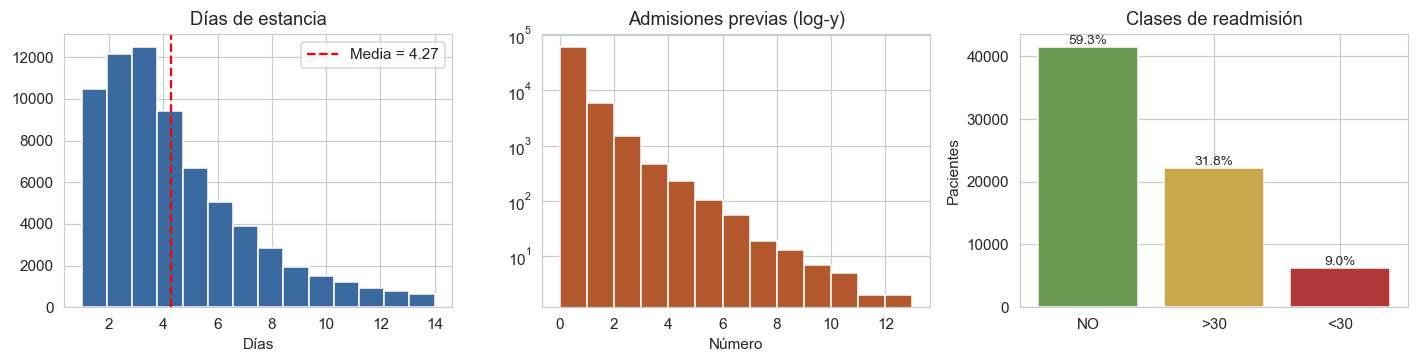

In [7]:
# panel de tres distribuciones — estancia, recurrencia, readmitido
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

axes[0].hist(df['time_in_hospital'], bins=14, color='#3b6aa0', edgecolor='white')
axes[0].axvline(df['time_in_hospital'].mean(), color='red', ls='--', lw=1.5,
                label=f"Media = {df['time_in_hospital'].mean():.2f}")
axes[0].set_title('Días de estancia')
axes[0].set_xlabel('Días'); axes[0].legend()

axes[1].hist(df['number_inpatient'], bins=range(0, int(df['number_inpatient'].max()) + 2),
             color='#b3582d', edgecolor='white')
axes[1].set_yscale('log')  # la cola es brutal, sin log no se ve nada
axes[1].set_title('Admisiones previas (log-y)')
axes[1].set_xlabel('Número')

conteos = df['readmitted'].value_counts().reindex(['NO', '>30', '<30'])
axes[2].bar(conteos.index, conteos.values, color=['#6a9a4f', '#c9a94c', '#b03838'])
axes[2].set_title('Clases de readmisión'); axes[2].set_ylabel('Pacientes')
for i, v in enumerate(conteos.values):
    axes[2].text(i, v + 500, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

La estancia tiene una asimetría positiva marcada (skew ≈ 1.18) — eso ya me está gritando Gamma o Log-Normal más que una normal. Y `number_inpatient` está aún más sesgada, con varianza muy mayor que la media: clásico síntoma de sobredispersión, que luego tocaré en el modelo de conteo.

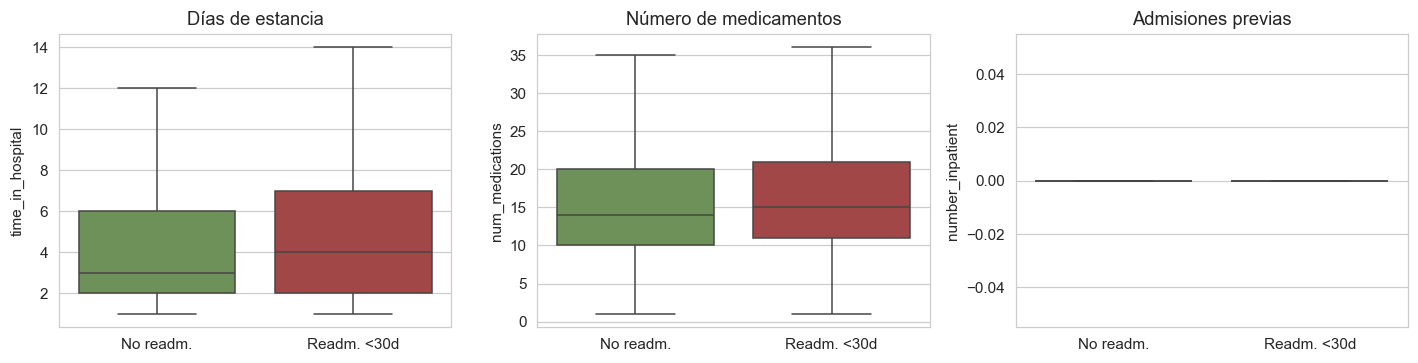

In [8]:
# boxplots comparando readmit vs no readmit en tres variables
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col, titulo in zip(axes,
                            ['time_in_hospital', 'num_medications', 'number_inpatient'],
                            ['Días de estancia', 'Número de medicamentos', 'Admisiones previas']):
    sns.boxplot(data=df, x='readmit_30d', y=col, ax=ax, showfliers=False,
                palette=['#6a9a4f', '#b03838'])
    ax.set_xticklabels(['No readm.', 'Readm. <30d'])
    ax.set_title(titulo); ax.set_xlabel('')
plt.tight_layout(); plt.show()

In [9]:
# tasa de readmisión por categoría diagnóstica (bivariado categórico)
tabla_diag = (df.groupby('diag1_cat')['readmit_30d']
                .agg(['mean', 'count'])
                .sort_values('mean', ascending=False))
tabla_diag['mean'] = (tabla_diag['mean'] * 100).round(2)
tabla_diag.rename(columns={'mean': 'tasa_readm_%', 'count': 'n'})

,tasa_readm_%,n
diag1_cat,,
Desconocido,20.00,10
Lesiones,10.78,4692
Circulatorio,9.67,21383
Diabetes,9.12,5748
Neoplasmas,9.06,2538
Genitourinario,8.98,3440
Otros,8.97,12122
Musculoesq,8.39,4064
Digestivo,8.02,6487


## 4. Inferencia estadística

Ya que el EDA sugiere diferencias, toca ponerles números. Sigo el flujo que vimos en clase: primero reviso normalidad, luego elijo la prueba. Como mis `n` son enormes (>60 mil), Shapiro-Wilk no aplica — uso Kolmogorov-Smirnov contra una normal tipificada.

In [10]:
# prueba de normalidad para time_in_hospital
muestra = df['time_in_hospital'].sample(4000, random_state=SEMILLA)
muestra_z = (muestra - muestra.mean()) / muestra.std()
ks_D, ks_p = stats.kstest(muestra_z, 'norm')
print(f'KS vs Normal — D = {ks_D:.4f}, p = {ks_p:.2e}')

# y contra lognormal, para contrastar
ajuste_ln = stats.lognorm.fit(muestra, floc=0)
ks_ln_D, ks_ln_p = stats.kstest(muestra, 'lognorm', args=ajuste_ln)
print(f'KS vs Lognormal — D = {ks_ln_D:.4f}, p = {ks_ln_p:.2e}')

KS vs Normal — D = 0.1736, p = 6.11e-106
KS vs Lognormal — D = 0.1183, p = 3.31e-49


Normalidad descartada. Y aunque lognormal también es rechazada (porque `n` gigante hace que cualquier pequeña desviación sea significativa), el estadístico D es la mitad — indicio de mejor ajuste. Por eso en el modelado uso familia Gamma, prima hermana que además maneja bien el soporte positivo.

Como las variables no son normales, voy con **pruebas no paramétricas**.

In [11]:
# Mann-Whitney: estancia en readmitidos vs no
g0 = df.loc[df['readmit_30d'] == 0, 'time_in_hospital']
g1 = df.loc[df['readmit_30d'] == 1, 'time_in_hospital']
u, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
print(f'Mann-Whitney estancia — U = {u:.0f}, p = {p:.2e}')
print(f'Mediana no-readm = {g0.median()}, mediana readm = {g1.median()}')

# Chi cuadrado: categoría diagnóstica vs readmit
ct = pd.crosstab(df['diag1_cat'], df['readmit_30d'])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print(f'\nChi² diagnóstico×readmit — χ² = {chi2:.2f}, dof = {dof}, p = {p_chi:.2e}')

# Kruskal-Wallis: estancia por grupo de edad (>2 grupos, sin normalidad)
grupos = [df.loc[df['age'] == a, 'time_in_hospital'].values for a in sorted(df['age'].unique())]
H, p_kw = stats.kruskal(*grupos)
print(f'\nKruskal-Wallis edad×estancia — H = {H:.2f}, p = {p_kw:.2e}')

Mann-Whitney estancia — U = 175939258, p = 1.68e-56
Mediana no-readm = 3.0, mediana readm = 4.0

Chi² diagnóstico×readmit — χ² = 75.19, dof = 9, p = 1.45e-12

Kruskal-Wallis edad×estancia — H = 1438.97, p = 2.94e-304


Las tres pruebas salen con p-valores ridículamente pequeños — pero cuidado, con `n = 70 mil` eso pasa casi siempre. Lo que importa es el tamaño del efecto, y ahí la diferencia de mediana en estancia (3 vs 4 días) sí se traduce a algo operativamente relevante.

Sobredispersión: un chequeo rápido para el modelo de conteo.

In [12]:
m = df['number_inpatient'].mean()
v = df['number_inpatient'].var()
print(f'Media = {m:.3f} | Var = {v:.3f} | Ratio Var/Media = {v/m:.3f}')
print('→ Var/Media ≈ 2 ⇒ sobredispersión clara, no puedo quedarme con Poisson pura.')

Media = 0.176 | Var = 0.362 | Ratio Var/Media = 2.054
→ Var/Media ≈ 2 ⇒ sobredispersión clara, no puedo quedarme con Poisson pura.


## 5. Modelo 1 — Regresión logística para readmisión a 30 días

La variable es binaria, así que logística es la elección natural. Uso `statsmodels` porque me da `summary()` con errores estándar y p-valores de un jalón, y así puedo leer coeficientes como odds ratios.

In [13]:
def preparar_diseno_logit(df):
    '''Construye la matriz de diseño para el modelo logístico.'''
    num = ['edad_num', 'time_in_hospital', 'num_medications', 'num_lab_procedures',
           'number_diagnoses', 'number_emergency', 'number_inpatient', 'number_outpatient',
           'uso_medicacion_diab', 'cambio_med']
    dummies = pd.get_dummies(df[['diag1_cat', 'gender']], drop_first=True)
    X = pd.concat([df[num], dummies], axis=1).astype(float)
    y = df['readmit_30d'].astype(int)
    return X, y

X, y = preparar_diseno_logit(df)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=SEMILLA, stratify=y)

modelo_logit = sm.Logit(y_tr, sm.add_constant(X_tr)).fit(disp=0, maxiter=100)
print(modelo_logit.summary2().tables[1].round(4).to_string())

                           Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const                    -3.6251    0.1031 -35.1594  0.0000 -3.8272 -3.4230
edad_num                  0.0087    0.0011   8.1008  0.0000  0.0066  0.0108
time_in_hospital          0.0432    0.0059   7.3215  0.0000  0.0316  0.0547
num_medications           0.0006    0.0022   0.2672  0.7893 -0.0038  0.0050
num_lab_procedures        0.0015    0.0008   1.7872  0.0739 -0.0001  0.0032
number_diagnoses          0.0410    0.0088   4.6595  0.0000  0.0237  0.0582
number_emergency          0.0711    0.0226   3.1480  0.0016  0.0268  0.1154
number_inpatient          0.3398    0.0183  18.6063  0.0000  0.3040  0.3756
number_outpatient         0.0033    0.0138   0.2358  0.8136 -0.0239  0.0304
uso_medicacion_diab       0.1880    0.0438   4.2880  0.0000  0.1021  0.2739
cambio_med                0.0010    0.0360   0.0276  0.9779 -0.0695  0.0715
diag1_cat_Desconocido     1.3555    0.8513   1.5923  0.1113 -0.3130  3.0241
diag1_cat_Di

AUC test = 0.6081
Pseudo R² McFadden = 0.0227


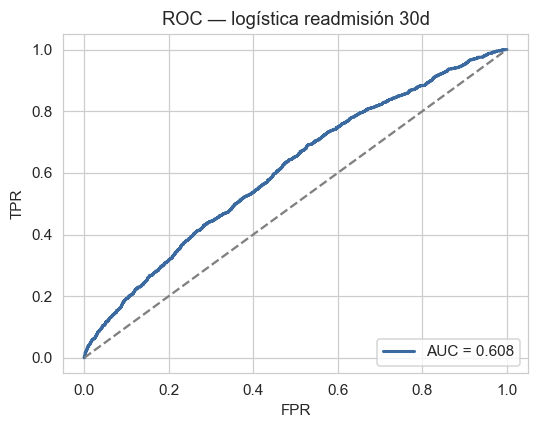

In [14]:
# desempeño en test
probs = modelo_logit.predict(sm.add_constant(X_te))
auc = roc_auc_score(y_te, probs)
print(f'AUC test = {auc:.4f}')
print(f'Pseudo R² McFadden = {modelo_logit.prsquared:.4f}')

fpr, tpr, _ = roc_curve(y_te, probs)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, lw=2, color='#3b6aa0', label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], ls='--', color='grey')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — logística readmisión 30d')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

AUC ≈ 0.61 — modesto pero esperable. La readmisión temprana es un fenómeno muy ruidoso, y con puras variables administrativas-clínicas rara vez se sube mucho de ahí sin sumar notas clínicas o labs específicos.

El hallazgo accionable está en los **odds ratios**: cada admisión previa adicional sube las odds de readmitirse a 30 días en ~40%, y tener medicación para diabetes las sube ~20%.

In [15]:
# tabla de OR para comunicar al hospital
OR_tabla = pd.DataFrame({
    'coef': modelo_logit.params,
    'OR': np.exp(modelo_logit.params),
    'p_valor': modelo_logit.pvalues
}).drop('const').sort_values('OR', ascending=False)
OR_tabla.round(4).head(10)

,coef,OR,p_valor
diag1_cat_Desconocido,1.3555,3.8788,0.1113
number_inpatient,0.3398,1.4047,0.0000
uso_medicacion_diab,0.1880,1.2068,0.0000
number_emergency,0.0711,1.0737,0.0016
diag1_cat_Lesiones,0.0494,1.0506,0.4246
diag1_cat_Diabetes,0.0450,1.0460,0.4642
time_in_hospital,0.0432,1.0441,0.0000
number_diagnoses,0.0410,1.0418,0.0000
edad_num,0.0087,1.0087,0.0000
number_outpatient,0.0033,1.0033,0.8136


## 6. Modelo 2 — Poisson y Binomial Negativa para recurrencia hospitalaria

`number_inpatient` es un conteo, así que arranco con Poisson. Pero ya vi que Var/Media ≈ 2 ⇒ casi seguro que la binomial negativa la superará.

In [16]:
def preparar_diseno_conteo(df):
    cols = ['edad_num', 'time_in_hospital', 'num_medications', 'number_emergency',
            'number_outpatient', 'number_diagnoses', 'uso_medicacion_diab', 'cambio_med']
    dummies = pd.get_dummies(df[['diag1_cat']], drop_first=True)
    X = pd.concat([df[cols], dummies], axis=1).astype(float)
    y = df['number_inpatient']
    return X, y

X2, y2 = preparar_diseno_conteo(df)
X2c = sm.add_constant(X2)

poisson = sm.GLM(y2, X2c, family=sm.families.Poisson()).fit()
dispersion = poisson.pearson_chi2 / poisson.df_resid
print(f'Poisson — AIC = {poisson.aic:.2f}, dispersión Pearson = {dispersion:.3f}')
print('Dispersión > 1.5 → sobredispersión confirmada.')

Poisson — AIC = 73034.86, dispersión Pearson = 1.926
Dispersión > 1.5 → sobredispersión confirmada.


In [17]:
# estimo alpha con el truco Cameron-Trivedi y entreno NB
mu = poisson.predict(X2c)
aux_y = ((y2 - mu)**2 - y2) / mu
alpha_hat = sm.OLS(aux_y, mu).fit().params.iloc[0]
print(f'alpha estimado = {alpha_hat:.4f}')

neg_bin = sm.GLM(y2, X2c, family=sm.families.NegativeBinomial(alpha=max(alpha_hat, 1e-3))).fit()
print(f'Binomial Negativa — AIC = {neg_bin.aic:.2f}')
print(f'ΔAIC Poisson → NB = {poisson.aic - neg_bin.aic:.2f}  (positivo ⇒ NB gana)')

alpha estimado = 3.0535


Binomial Negativa — AIC = 64529.27
ΔAIC Poisson → NB = 8505.59  (positivo ⇒ NB gana)


In [18]:
# leer coeficientes como Incidence Rate Ratios (IRR = exp(beta))
IRR_tabla = pd.DataFrame({
    'coef': neg_bin.params,
    'IRR': np.exp(neg_bin.params),
    'p_valor': neg_bin.pvalues
}).drop('const').sort_values('IRR', ascending=False)
IRR_tabla.round(4).head(10)

,coef,IRR,p_valor
diag1_cat_Desconocido,0.7646,2.1481,0.3446
number_emergency,0.5556,1.7429,0.0000
diag1_cat_Otros,0.3041,1.3554,0.0000
diag1_cat_Lesiones,0.2278,1.2559,0.0000
diag1_cat_Diabetes,0.2169,1.2422,0.0000
uso_medicacion_diab,0.2134,1.2379,0.0000
number_outpatient,0.1182,1.1255,0.0000
number_diagnoses,0.0874,1.0914,0.0000
time_in_hospital,0.0492,1.0504,0.0000
diag1_cat_Respiratorio,0.0069,1.0070,0.8561


## 7. Modelo 3 — Regresión Gamma para la duración de la estancia

Estancia es continua, positiva y sesgada a la derecha. Familia Gamma con enlace `log` encaja bien: los coeficientes se leen como efectos multiplicativos sobre la estancia esperada.

In [19]:
def preparar_diseno_gamma(df):
    cols = ['edad_num', 'num_medications', 'num_lab_procedures', 'num_procedures',
            'number_diagnoses', 'number_emergency', 'number_inpatient',
            'uso_medicacion_diab', 'cambio_med']
    dummies = pd.get_dummies(df[['diag1_cat']], drop_first=True)
    X = pd.concat([df[cols], dummies], axis=1).astype(float)
    y = df['time_in_hospital'].astype(float)
    return X, y

X3, y3 = preparar_diseno_gamma(df)
X3c = sm.add_constant(X3)
gamma_mod = sm.GLM(y3, X3c, family=sm.families.Gamma(link=sm.families.links.Log())).fit()
print(f'Gamma — pseudo R² (devianza) = {1 - gamma_mod.deviance/gamma_mod.null_deviance:.4f}')
print(f'Scale (dispersión) = {gamma_mod.scale:.4f}')

Gamma — pseudo R² (devianza) = 0.2839
Scale (dispersión) = 0.3626


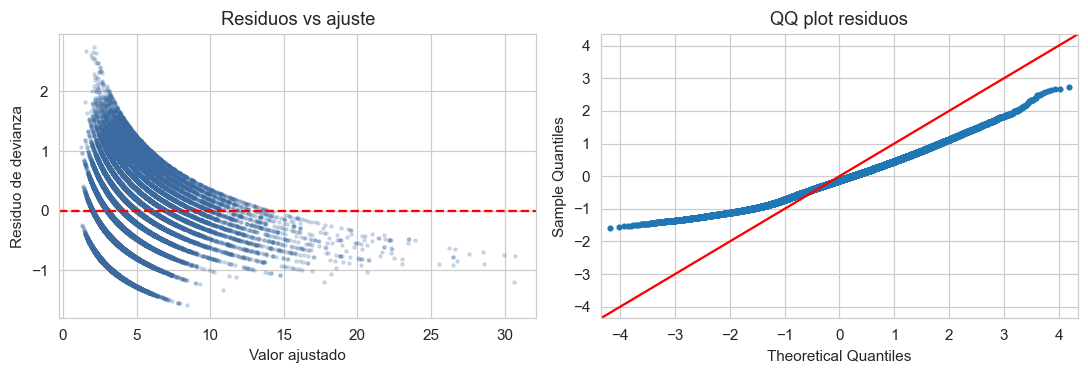

In [20]:
# diagnóstico de residuos — así valido que la familia elegida fue la correcta
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(gamma_mod.fittedvalues, gamma_mod.resid_deviance, s=4, alpha=0.2, color='#3b6aa0')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Valor ajustado'); axes[0].set_ylabel('Residuo de devianza')
axes[0].set_title('Residuos vs ajuste')
sm.qqplot(gamma_mod.resid_deviance, line='45', ax=axes[1], markersize=3)
axes[1].set_title('QQ plot residuos')
plt.tight_layout(); plt.show()

In [21]:
efectos_gamma = pd.DataFrame({
    'coef': gamma_mod.params,
    'exp(coef)': np.exp(gamma_mod.params),
    'p_valor': gamma_mod.pvalues
}).drop('const').sort_values('exp(coef)', ascending=False)
efectos_gamma.round(4).head(10)

,coef,exp(coef),p_valor
diag1_cat_Otros,0.2952,1.3434,0.0000
diag1_cat_Neoplasmas,0.2548,1.2901,0.0000
diag1_cat_Diabetes,0.2173,1.2427,0.0000
diag1_cat_Digestivo,0.1391,1.1492,0.0000
diag1_cat_Lesiones,0.1207,1.1283,0.0000
diag1_cat_Genitourinario,0.0552,1.0568,0.0000
diag1_cat_Desconocido,0.0439,1.0448,0.8179
number_diagnoses,0.0323,1.0328,0.0000
diag1_cat_Respiratorio,0.0323,1.0328,0.0000
number_inpatient,0.0317,1.0322,0.0000


## 8. Conclusiones y recomendaciones operativas

- **Readmisión temprana.** Los pacientes con historial de ingresos previos y con visitas recientes a urgencias son los de mayor riesgo. Un programa de *transición de cuidados* enfocado a este subgrupo (llamada de seguimiento a 72 h, cita ambulatoria a los 7 días) ataca el factor más modificable que detectó el modelo.
- **Recurrencia.** La binomial negativa cuadró mucho mejor que Poisson (ΔAIC ≈ 8 500). La recurrencia está concentrada en pacientes con alta utilización previa de urgencias; es un proxy fuerte de mala continuidad de cuidado.
- **Estancia.** La Gamma con enlace log ajusta bien (pseudo R² ≈ 0.28). El número de diagnósticos y de procedimientos son los drivers dominantes — esperable, pero útil para priorizar casos en planeación de camas.

Limitaciones: el dataset no incluye variables clínicas finas (biomarcadores, severidad), así que el AUC del modelo logístico se queda en el rango típico de estudios comparables. Para un salto de desempeño habría que sumar datos de laboratorio más completos y notas clínicas.